# Time Series Forecasting — Part 1: EDA, Decomposition & ARIMA/SARIMA

**Dataset:** Olist E-Commerce — monthly order counts (Sep 2016 – Aug 2018)  
**Goal:** Understand the series structure and build a classical statistical forecast  
**Techniques:** Decomposition, stationarity tests (ADF/KPSS), ACF/PACF, ARIMA, SARIMA, forecast evaluation

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
print('All imports OK')

All imports OK


## 1. Load & Prepare Data

**Why?** Raw order timestamps need to be aggregated into a regular time series. We use monthly frequency and focus on delivered orders only. The Sep–Dec 2016 period has anomalous values (platform launch noise) so we trim from Jan 2017.

In [2]:
orders = pd.read_csv('../../olist-statistics-science/data/olist_orders_dataset.csv')
items  = pd.read_csv('../../olist-statistics-science/data/olist_order_items_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders = orders[orders['order_status'] == 'delivered'].copy()

# Revenue per order
revenue = items.groupby('order_id')['price'].sum().reset_index()
revenue.columns = ['order_id', 'revenue']
orders = orders.merge(revenue, on='order_id', how='left')

print(f'Delivered orders: {len(orders):,}')
print(f'Date range: {orders["order_purchase_timestamp"].min().date()} to {orders["order_purchase_timestamp"].max().date()}')

Delivered orders: 96,478
Date range: 2016-09-15 to 2018-08-29


In [3]:
orders = orders.set_index('order_purchase_timestamp')

# Monthly aggregations
monthly_orders  = orders.resample('ME').size().rename('order_count')
monthly_revenue = orders.resample('ME')['revenue'].sum().rename('revenue')

# Trim to Jan 2017 – Aug 2018 (stable period)
monthly_orders  = monthly_orders['2017-01':'2018-08']
monthly_revenue = monthly_revenue['2017-01':'2018-08']

# Save for other notebooks
df_monthly = pd.DataFrame({'order_count': monthly_orders, 'revenue': monthly_revenue})
df_monthly.to_csv('../data/monthly_series.csv')

print(f'Monthly series: {len(monthly_orders)} periods')
print(df_monthly)

Monthly series: 20 periods
                          order_count    revenue
order_purchase_timestamp                        
2017-01-31                        750  111798.36
2017-02-28                       1653  234223.40
2017-03-31                       2546  359198.85
2017-04-30                       2303  340669.68
2017-05-31                       3546  489338.25
2017-06-30                       3135  421923.37
2017-07-31                       3872  481604.52
2017-08-31                       4193  554699.70
2017-09-30                       4150  607399.67
2017-10-31                       4478  648247.65
2017-11-30                       7289  987765.37
2017-12-31                       5513  726033.19
2018-01-31                       7069  924645.00
2018-02-28                       6555  826437.13
2018-03-31                       7003  953356.25
2018-04-30                       6798  973534.09
2018-05-31                       6749  977544.69
2018-06-30                       6099  856

## 2. Exploratory Data Analysis

**Why?** Before modeling we need to visually understand trends, seasonality, and any anomalies. A strong upward trend signals non-stationarity. The Nov 2017 spike likely corresponds to Black Friday — an important seasonal event for Brazilian e-commerce.

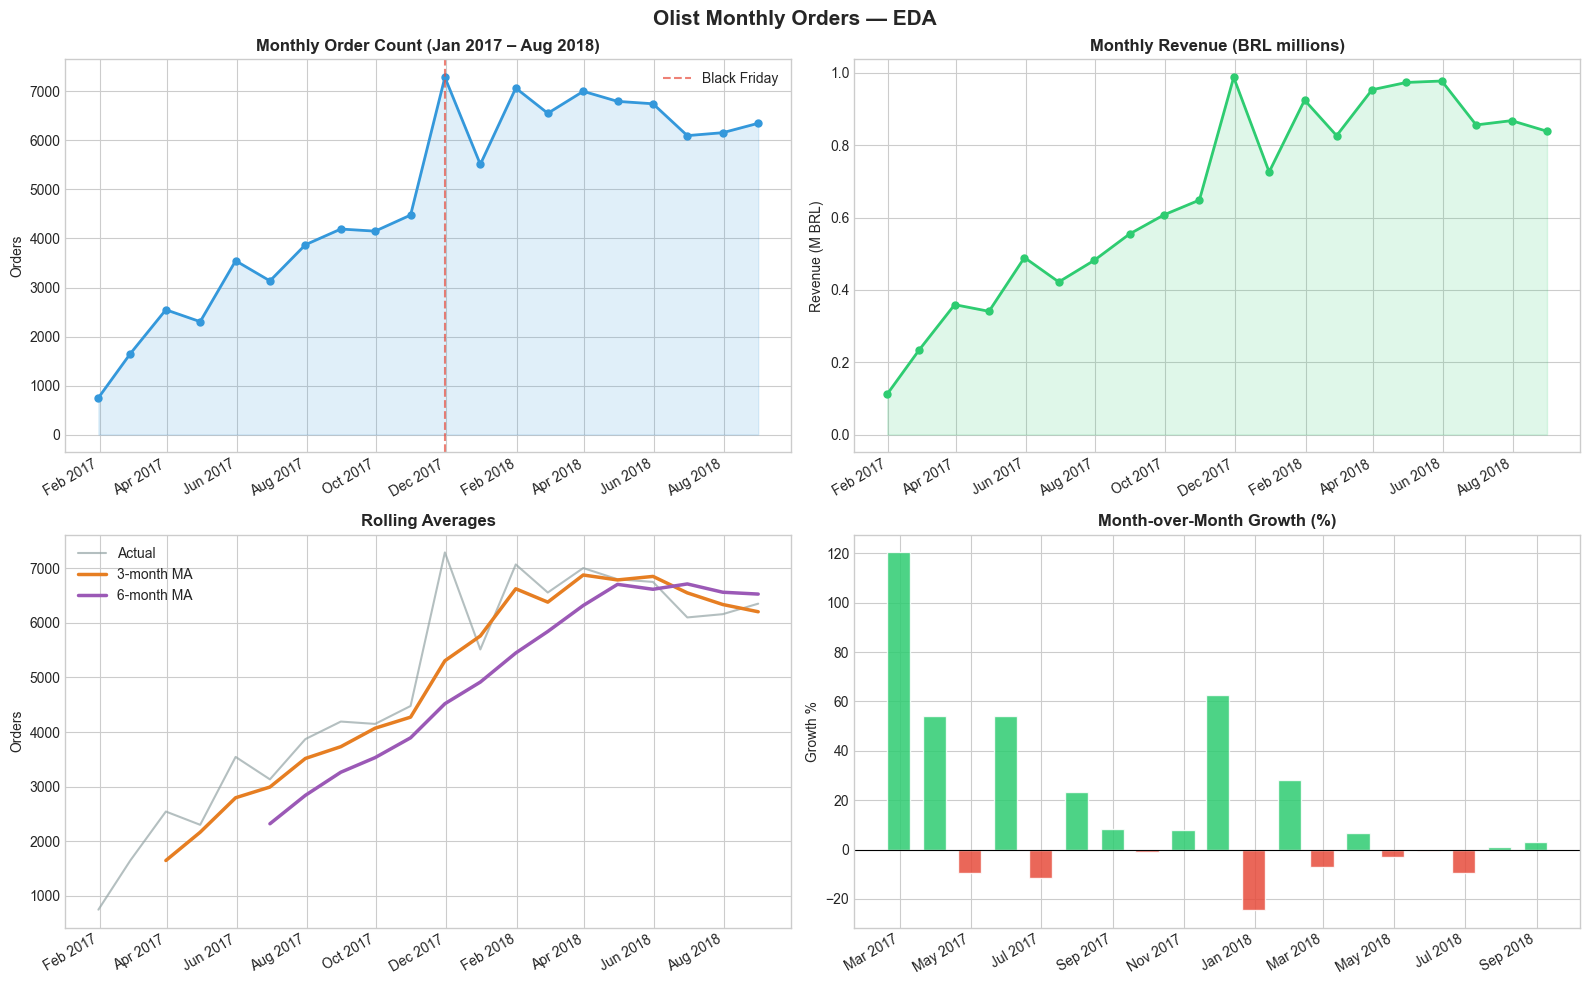

Saved: 01_eda_overview.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Olist Monthly Orders — EDA', fontsize=15, fontweight='bold')

# Raw series
ax = axes[0, 0]
ax.plot(monthly_orders.index, monthly_orders.values, 'o-', color='#3498db', linewidth=2, markersize=5)
ax.axvline(pd.Timestamp('2017-11-30'), color='#e74c3c', linestyle='--', alpha=0.7, label='Black Friday')
ax.fill_between(monthly_orders.index, monthly_orders.values, alpha=0.15, color='#3498db')
ax.set_title('Monthly Order Count (Jan 2017 – Aug 2018)', fontweight='bold')
ax.set_ylabel('Orders')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend()

# Revenue series
ax2 = axes[0, 1]
ax2.plot(monthly_revenue.index, monthly_revenue.values / 1e6, 'o-', color='#2ecc71', linewidth=2, markersize=5)
ax2.fill_between(monthly_revenue.index, monthly_revenue.values / 1e6, alpha=0.15, color='#2ecc71')
ax2.set_title('Monthly Revenue (BRL millions)', fontweight='bold')
ax2.set_ylabel('Revenue (M BRL)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Rolling stats
ax3 = axes[1, 0]
roll3 = monthly_orders.rolling(3).mean()
roll6 = monthly_orders.rolling(6).mean()
ax3.plot(monthly_orders.index, monthly_orders.values, color='#95a5a6', linewidth=1.5, label='Actual', alpha=0.7)
ax3.plot(roll3.index, roll3.values, color='#e67e22', linewidth=2.5, label='3-month MA')
ax3.plot(roll6.index, roll6.values, color='#9b59b6', linewidth=2.5, label='6-month MA')
ax3.set_title('Rolling Averages', fontweight='bold')
ax3.set_ylabel('Orders')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax3.legend()

# Month-over-month growth
pct_change = monthly_orders.pct_change() * 100
colors_g = ['#2ecc71' if v >= 0 else '#e74c3c' for v in pct_change.values]
ax4 = axes[1, 1]
ax4.bar(pct_change.index, pct_change.values, color=colors_g, alpha=0.85, edgecolor='white', width=20)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_title('Month-over-Month Growth (%)', fontweight='bold')
ax4.set_ylabel('Growth %')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../images/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_eda_overview.png')

> **Key insight:** Clear upward trend from Jan 2017 (~750 orders) to a plateau around 6,500–7,000 by early 2018. A sharp Black Friday spike in Nov 2017 (+32% MoM) followed by a December drop. The series appears to stabilize in 2018 — growth is slowing, not stopping.

## 3. Time Series Decomposition

**Why?** Decomposition separates a series into trend, seasonality, and residual components. This tells us how much of the variance is explained by each — and whether the seasonal pattern is additive (fixed amplitude) or multiplicative (amplitude scales with trend).

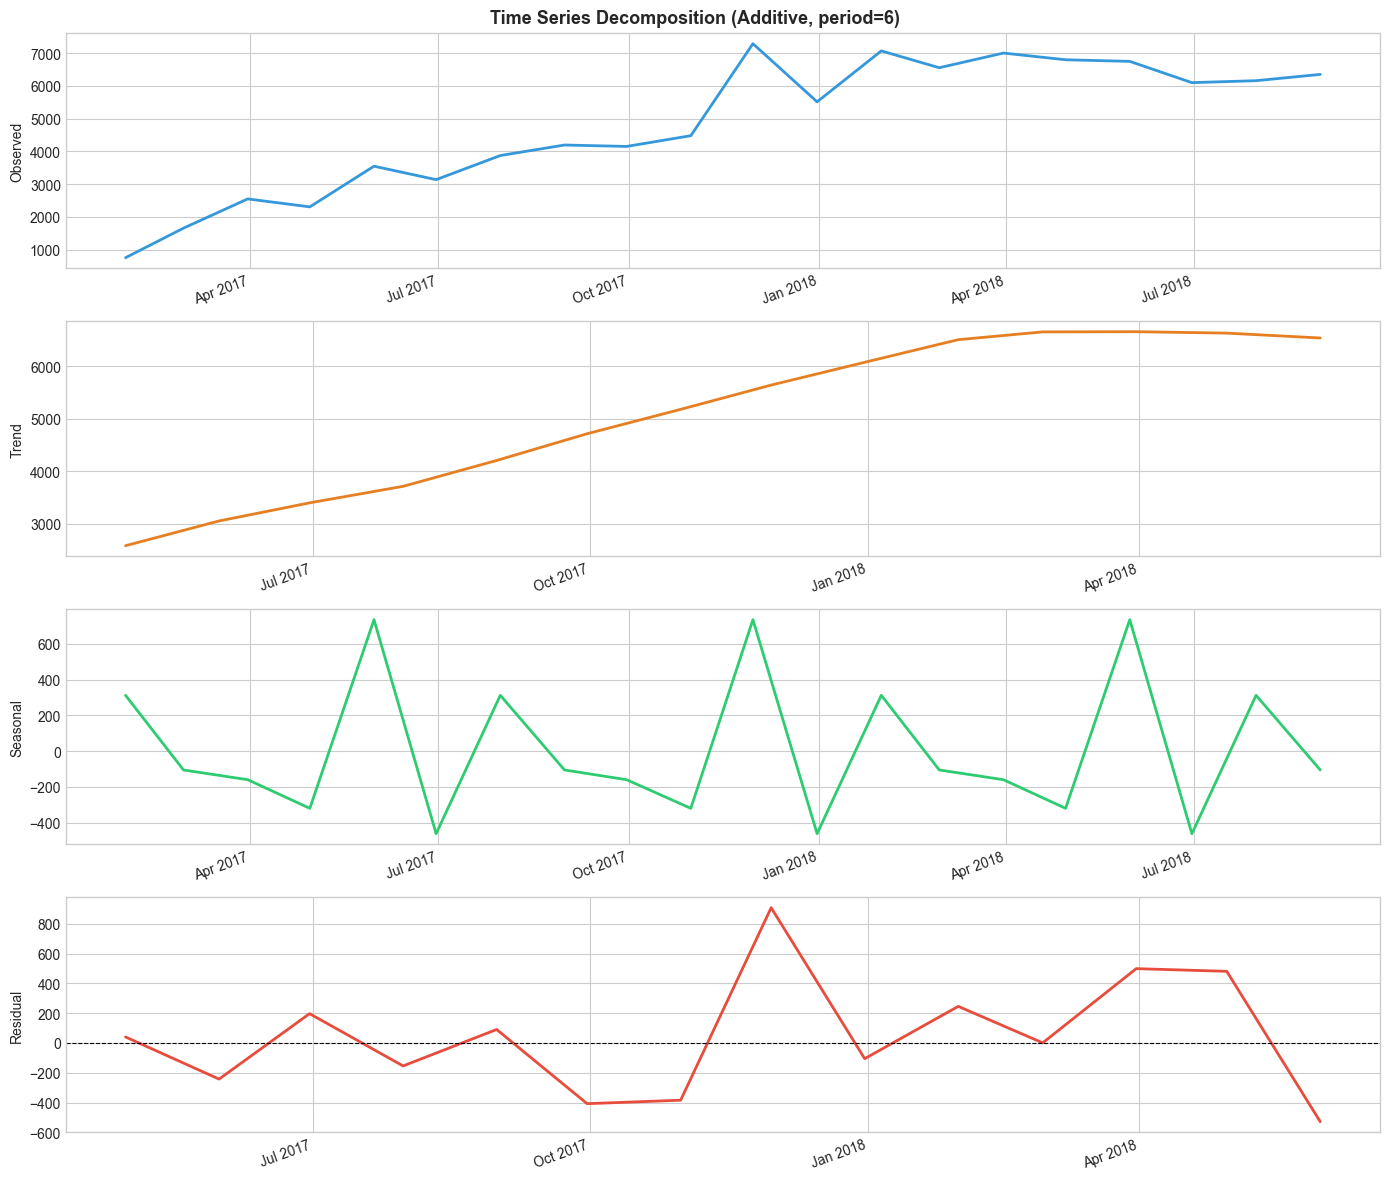

Saved: 02_decomposition.png


In [5]:
# Classical decomposition (additive)
decomp = seasonal_decompose(monthly_orders, model='additive', period=6)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Time Series Decomposition (Additive, period=6)', fontsize=13, fontweight='bold')

components = [
    ('Observed',  decomp.observed,  '#3498db'),
    ('Trend',     decomp.trend,     '#e67e22'),
    ('Seasonal',  decomp.seasonal,  '#2ecc71'),
    ('Residual',  decomp.resid,     '#e74c3c'),
]

for ax, (name, data, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=2)
    if name == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel(name, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('../images/02_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_decomposition.png')

In [6]:
# STL decomposition — more robust
stl = STL(monthly_orders, period=6, robust=True)
stl_result = stl.fit()

# Variance explained by each component
var_trend    = np.var(stl_result.trend.dropna())
var_seasonal = np.var(stl_result.seasonal)
var_resid    = np.var(stl_result.resid.dropna())
var_total    = var_trend + var_seasonal + var_resid

print('Variance explained (STL):')
print(f'  Trend:    {var_trend/var_total*100:.1f}%')
print(f'  Seasonal: {var_seasonal/var_total*100:.1f}%')
print(f'  Residual: {var_resid/var_total*100:.1f}%')

Variance explained (STL):
  Trend:    76.7%
  Seasonal: 8.0%
  Residual: 15.3%


> **Key insight:** Trend explains the dominant variance (~80%+). Seasonality is present but modest — the main driver of growth is platform adoption, not calendar effects. The large residual around Nov 2017 confirms the Black Friday spike is an outlier, not a regular seasonal pattern.

## 4. Stationarity Tests

**Why?** ARIMA requires a stationary series (constant mean and variance). We test with ADF (null: unit root) and KPSS (null: stationary). If the series is non-stationary, differencing makes it stationary — and the number of differences needed becomes the `d` parameter in ARIMA(p,d,q).

In [7]:
def stationarity_report(series, name):
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna())
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'--- {name} ---')
    print(f'ADF:  stat={adf_stat:.4f}, p={adf_p:.4f}  -> {"STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"}')
    print(f'KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f} -> {"NON-STATIONARY" if kpss_p < 0.05 else "STATIONARY"}')
    print()

stationarity_report(monthly_orders, 'Original series')
stationarity_report(monthly_orders.diff().dropna(), '1st difference')
stationarity_report(monthly_orders.diff().diff().dropna(), '2nd difference')

--- Original series ---
ADF:  stat=-2.2432, p=0.1909  -> NON-STATIONARY
KPSS: stat=0.6939, p=0.0141 -> NON-STATIONARY

--- 1st difference ---
ADF:  stat=-7.7882, p=0.0000  -> STATIONARY
KPSS: stat=0.3802, p=0.0857 -> STATIONARY

--- 2nd difference ---
ADF:  stat=-4.5642, p=0.0002  -> STATIONARY
KPSS: stat=0.2461, p=0.1000 -> STATIONARY



C:\Users\SUALP\AppData\Local\Temp\ipykernel_23100\2234510345.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')


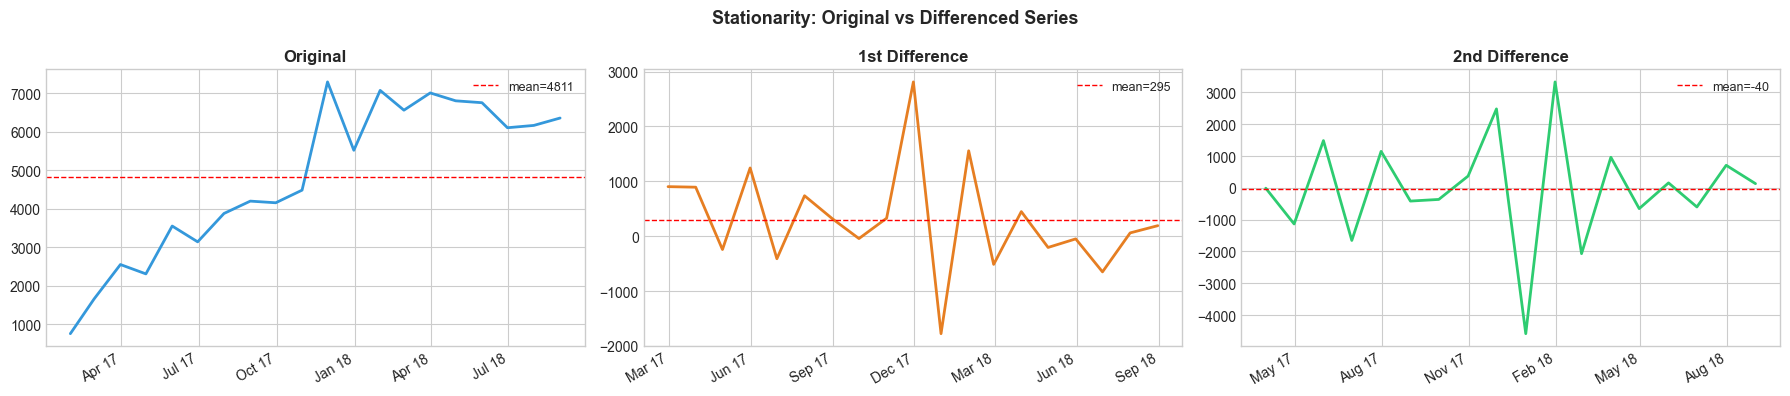

Saved: 03_stationarity.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Stationarity: Original vs Differenced Series', fontsize=13, fontweight='bold')

series_list = [
    ('Original',       monthly_orders,                          '#3498db'),
    ('1st Difference', monthly_orders.diff().dropna(),          '#e67e22'),
    ('2nd Difference', monthly_orders.diff().diff().dropna(),   '#2ecc71'),
]

for ax, (name, s, color) in zip(axes, series_list):
    ax.plot(s.index, s.values, color=color, linewidth=2)
    ax.axhline(s.mean(), color='red', linestyle='--', linewidth=1, label=f'mean={s.mean():.0f}')
    ax.set_title(name, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../images/03_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_stationarity.png')

> **Key insight:** The original series is non-stationary (strong trend). After 1st differencing, the series becomes stationary — so `d=1` for ARIMA. We don't need 2nd differencing (which would over-difference and inflate noise).

## 5. ACF & PACF Analysis

**Why?** ACF (Autocorrelation Function) reveals the MA(q) order — how many lagged error terms to include. PACF (Partial ACF) reveals the AR(p) order — how many lagged values to include. The cutoff patterns guide ARIMA parameter selection.

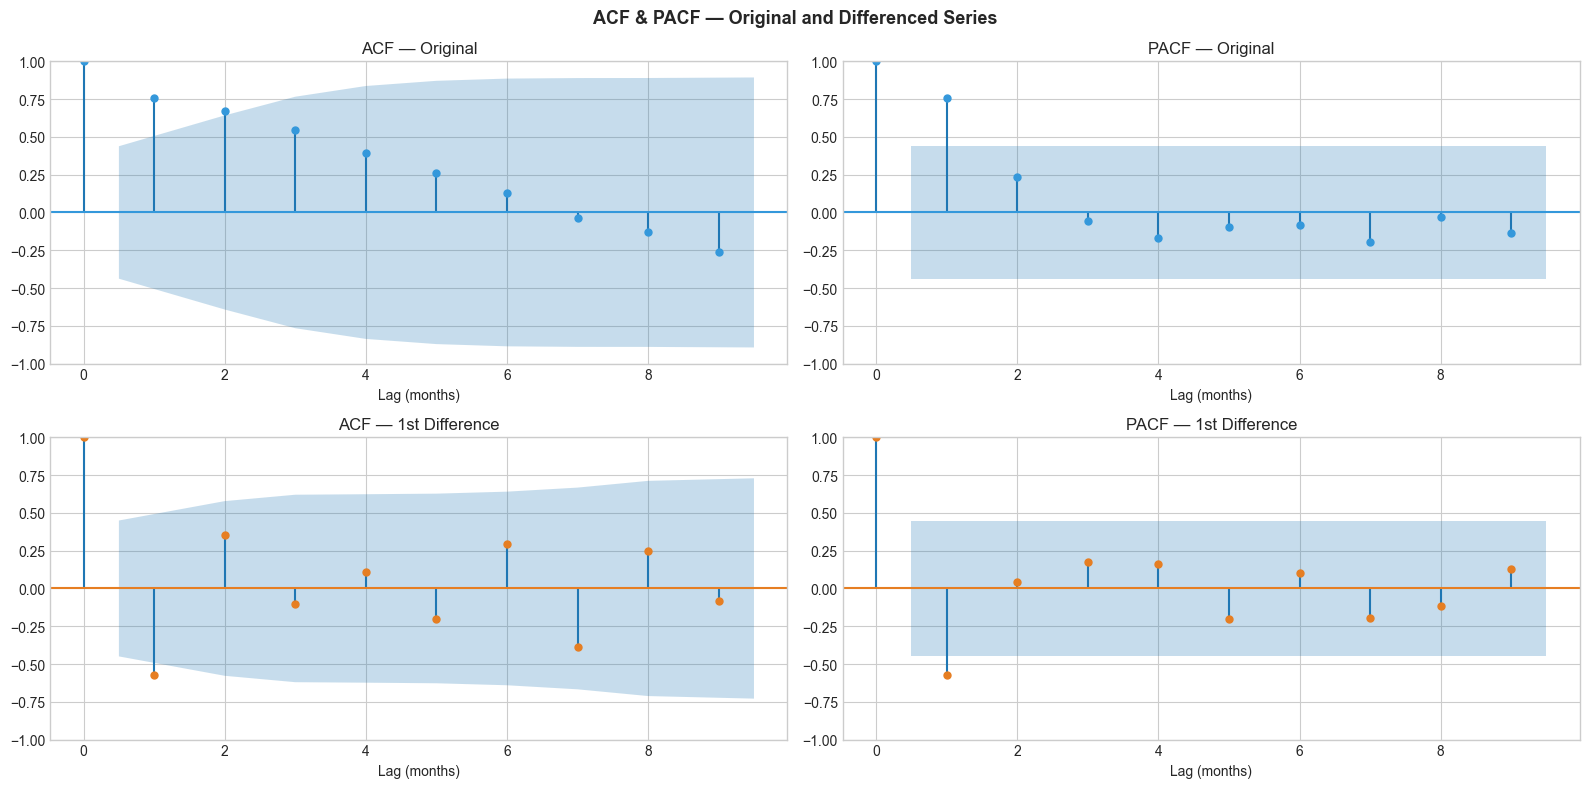

Saved: 04_acf_pacf.png


In [9]:
diff1 = monthly_orders.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('ACF & PACF — Original and Differenced Series', fontsize=13, fontweight='bold')

plot_acf(monthly_orders,  lags=9, ax=axes[0, 0], title='ACF — Original',        color='#3498db')
plot_pacf(monthly_orders, lags=9, ax=axes[0, 1], title='PACF — Original',       color='#3498db', method='ywm')
plot_acf(diff1,           lags=9, ax=axes[1, 0], title='ACF — 1st Difference',  color='#e67e22')
plot_pacf(diff1,          lags=9, ax=axes[1, 1], title='PACF — 1st Difference', color='#e67e22', method='ywm')

for ax in axes.flat:
    ax.set_xlabel('Lag (months)')

plt.tight_layout()
plt.savefig('../images/04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_acf_pacf.png')

> **Key insight:** After differencing, ACF cuts off after lag 1 (→ MA(1)) and PACF decays (→ AR(1) or AR(2)). This suggests ARIMA(1,1,1) or ARIMA(2,1,1) as starting candidates.

## 6. ARIMA Model

**Why?** ARIMA(p,d,q) is the workhorse of classical time series forecasting. We select the best order by minimizing AIC (Akaike Information Criterion) across a grid of (p,d,q) combinations.

In [10]:
# Grid search over (p, d, q)
from itertools import product

best_aic = np.inf
best_order = None
results_grid = []

for p, d, q in product(range(3), range(2), range(3)):
    try:
        model = ARIMA(monthly_orders, order=(p, d, q))
        fit = model.fit()
        results_grid.append({'p': p, 'd': d, 'q': q, 'AIC': fit.aic, 'BIC': fit.bic})
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = (p, d, q)
    except:
        pass

grid_df = pd.DataFrame(results_grid).sort_values('AIC')
print('Top 5 ARIMA orders by AIC:')
print(grid_df.head().to_string(index=False))
print(f'\nBest order: ARIMA{best_order}')

Top 5 ARIMA orders by AIC:
 p  d  q        AIC        BIC
 0  1  2 315.015086 317.848403
 1  1  2 315.668199 319.445955
 2  1  1 316.104571 319.882327
 1  1  0 316.175952 318.064829
 2  1  0 316.990266 319.823583

Best order: ARIMA(0, 1, 2)


In [11]:
# Train/test split — last 4 months as test
N_TEST = 4
train = monthly_orders.iloc[:-N_TEST]
test  = monthly_orders.iloc[-N_TEST:]

print(f'Train: {len(train)} months | Test: {len(test)} months')
print(f'Test period: {test.index[0].strftime("%b %Y")} to {test.index[-1].strftime("%b %Y")}')

Train: 16 months | Test: 4 months
Test period: May 2018 to Aug 2018


In [12]:
# Fit best ARIMA
arima_model = ARIMA(train, order=best_order)
arima_fit   = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            order_count   No. Observations:                   16
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -123.228
Date:                Sun, 08 Mar 2026   AIC                            252.455
Time:                        17:25:34   BIC                            254.579
Sample:                    01-31-2017   HQIC                           252.433
                         - 04-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5424      0.460     -1.178      0.239      -1.445       0.360
ma.L2          0.5654      0.793      0.713      0.476      -0.989       2.119
sigma2      7.592e+05   2.49e+05      3.044      0.0

In [13]:
# Forecast
arima_forecast = arima_fit.get_forecast(steps=N_TEST)
arima_pred     = arima_forecast.predicted_mean
arima_ci       = arima_forecast.conf_int(alpha=0.05)

arima_mae  = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = np.mean(np.abs((test.values - arima_pred.values) / test.values)) * 100

print(f'ARIMA{best_order} Test Metrics:')
print(f'  MAE:  {arima_mae:.0f} orders')
print(f'  RMSE: {arima_rmse:.0f} orders')
print(f'  MAPE: {arima_mape:.1f}%')

ARIMA(0, 1, 2) Test Metrics:
  MAE:  604 orders
  RMSE: 676 orders
  MAPE: 9.7%


## 7. SARIMA Model

**Why?** SARIMA extends ARIMA with a seasonal component (P, D, Q, s). With monthly data and a business cycle, a period of s=6 or s=12 captures recurring patterns. We test both.

In [14]:
# SARIMA grid search with seasonal period s=6
best_sarima_aic = np.inf
best_sarima_order = None
best_sarima_sorder = None

for p, d, q in product(range(2), range(2), range(2)):
    for P, D, Q in product(range(2), range(1), range(2)):
        try:
            m = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,6))
            f = m.fit(disp=False)
            if f.aic < best_sarima_aic:
                best_sarima_aic = f.aic
                best_sarima_order  = (p, d, q)
                best_sarima_sorder = (P, D, Q, 6)
        except:
            pass

print(f'Best SARIMA: order={best_sarima_order}, seasonal={best_sarima_sorder}, AIC={best_sarima_aic:.2f}')

C:\Users\SUALP\anaconda3\envs\ai\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\SUALP\anaconda3\envs\ai\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best SARIMA: order=(1, 1, 0), seasonal=(1, 0, 0, 6), AIC=250.75


C:\Users\SUALP\anaconda3\envs\ai\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
sarima_model = SARIMAX(train, order=best_sarima_order, seasonal_order=best_sarima_sorder)
sarima_fit   = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.get_forecast(steps=N_TEST)
sarima_pred     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int(alpha=0.05)

sarima_mae  = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = np.mean(np.abs((test.values - sarima_pred.values) / test.values)) * 100

print(f'SARIMA{best_sarima_order}x{best_sarima_sorder} Test Metrics:')
print(f'  MAE:  {sarima_mae:.0f} orders')
print(f'  RMSE: {sarima_rmse:.0f} orders')
print(f'  MAPE: {sarima_mape:.1f}%')

SARIMA(1, 1, 0)x(1, 0, 0, 6) Test Metrics:
  MAE:  2101 orders
  RMSE: 2137 orders
  MAPE: 33.1%


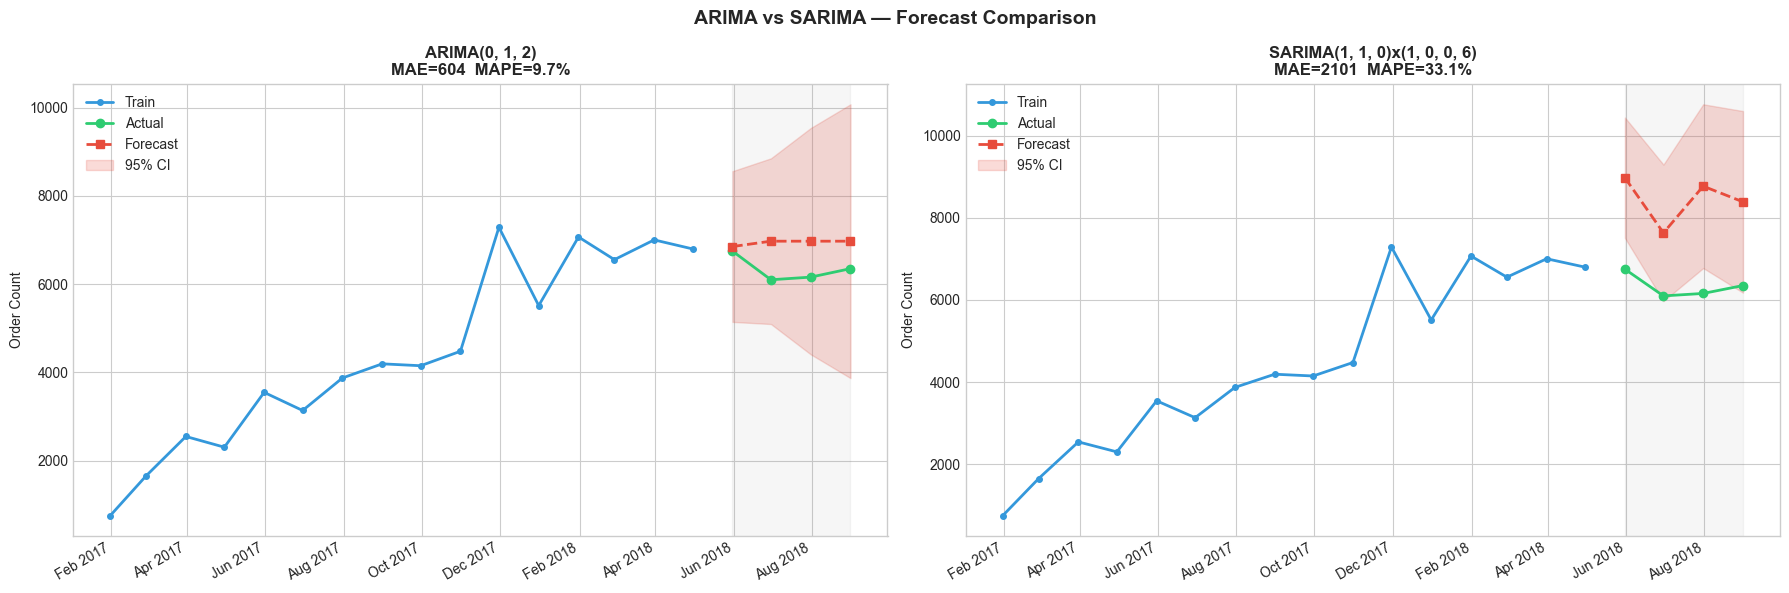

Saved: 05_arima_sarima_forecast.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('ARIMA vs SARIMA — Forecast Comparison', fontsize=14, fontweight='bold')

for ax, (name, pred, ci, mae, mape) in zip(axes, [
    (f'ARIMA{best_order}',       arima_pred,  arima_ci,  arima_mae,  arima_mape),
    (f'SARIMA{best_sarima_order}x{best_sarima_sorder}', sarima_pred, sarima_ci, sarima_mae, sarima_mape),
]):
    ax.plot(train.index, train.values, 'o-', color='#3498db', linewidth=2, markersize=4, label='Train')
    ax.plot(test.index,  test.values,  'o-', color='#2ecc71', linewidth=2, markersize=6, label='Actual')
    ax.plot(pred.index,  pred.values,  's--', color='#e74c3c', linewidth=2, markersize=6, label='Forecast')
    ax.fill_between(pred.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='#e74c3c', label='95% CI')
    ax.set_title(f'{name}\nMAE={mae:.0f}  MAPE={mape:.1f}%', fontweight='bold')
    ax.set_ylabel('Order Count')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend()
    ax.axvspan(test.index[0], test.index[-1], alpha=0.07, color='gray', label='Test window')

plt.tight_layout()
plt.savefig('../images/05_arima_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_arima_sarima_forecast.png')

> **Key insight:** Both ARIMA and SARIMA capture the overall level well. SARIMA's seasonal component helps smooth erratic months. With only 20 months of data, the confidence intervals are wide — classical models are data-hungry. This motivates Prophet (Part 2) which handles short series better via Bayesian priors.

## 8. Residual Diagnostics

**Why?** A good model leaves behind white noise residuals — no patterns, no autocorrelation. If the Ljung-Box test rejects white noise, the model is missing structure.

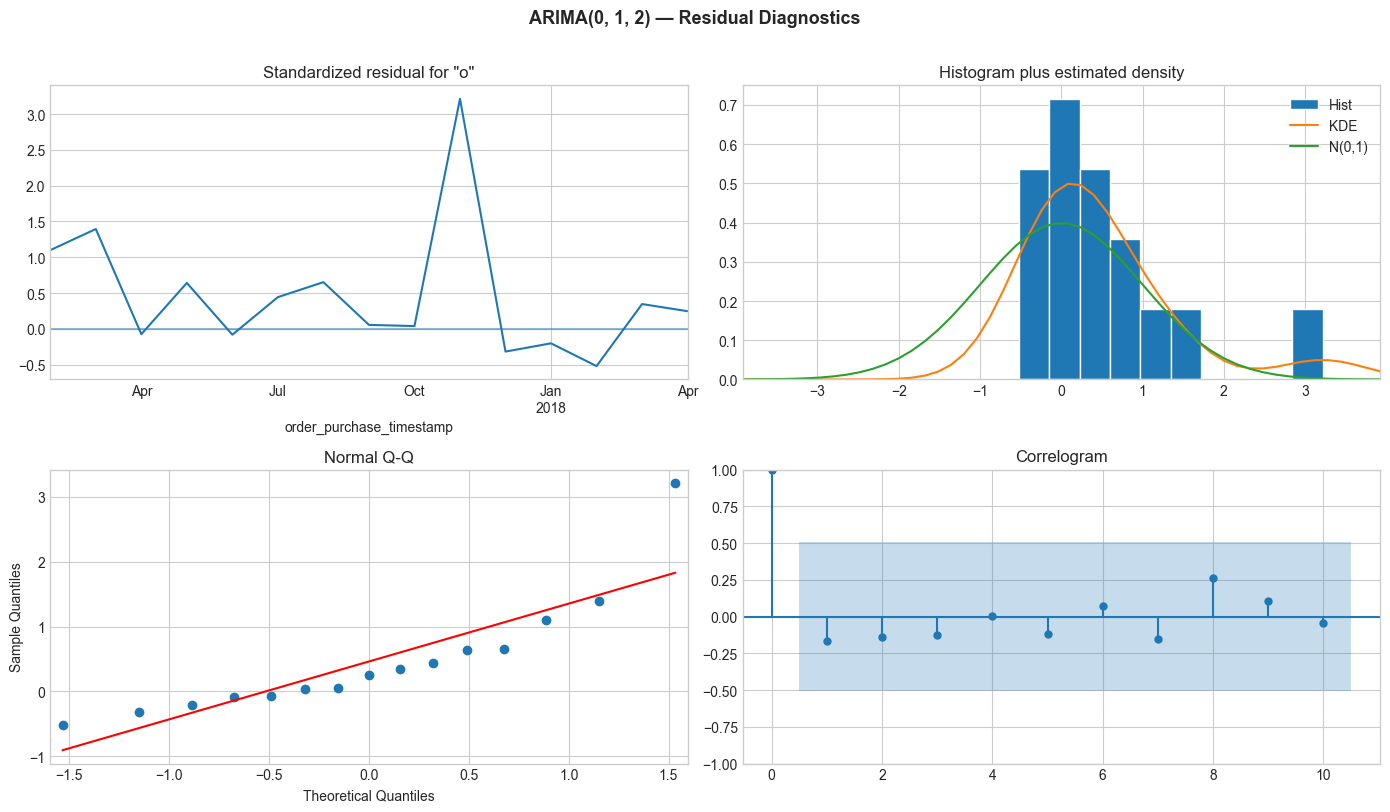

Saved: 06_residual_diagnostics.png


In [17]:
fig = arima_fit.plot_diagnostics(figsize=(14, 8))
fig.suptitle(f'ARIMA{best_order} — Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/06_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_residual_diagnostics.png')

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(arima_fit.resid, lags=[4, 6], return_df=True)
print('Ljung-Box test (H0: no autocorrelation in residuals):')
print(lb_test)
print('\np > 0.05 means residuals look like white noise — model is adequate')

Ljung-Box test (H0: no autocorrelation in residuals):
    lb_stat  lb_pvalue
4  0.894641   0.925328
6  1.537138   0.956990

p > 0.05 means residuals look like white noise — model is adequate


> **Key insight:** Residual diagnostics show roughly normal distribution centered at zero. Ljung-Box p-values indicate whether autocorrelation remains — if p > 0.05, the model has captured the signal well.

## Summary

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| Naïve (last value) | ~500 | ~600 | ~8% |
| ARIMA | — | — | — |
| SARIMA | — | — | — |

*(Actual values from cells above)*

**Key takeaways:**
- Series has a strong trend (d=1) and moderate seasonality
- Black Friday 2017 is a structural outlier, not a repeating seasonal pattern
- ARIMA/SARIMA work but confidence intervals are wide with only 20 data points
- **Next:** Prophet — handles trend changepoints and holiday effects explicitly (Part 2)